# Project: Neutrino Portal at the Muon Collider

## Load Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import pathlib
import ast
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json

## Calculate Observables

-  this function reads the particles in a csv file and exports a data frame

In [2]:
data = pd.read_csv("output_events_0.125GeV/events_22.53.csv.zip")

In [3]:
data

,ievent,iparticle,truth_energy,pid,px,py,pz,e,parent_pid1,parent_pid2
0,0,0,22.53,-13,-1.771,-1.050,9.336,9.561,14,2
1,0,1,22.53,39,-0.151,0.601,1.311,1.455,39,39
2,0,2,22.53,-211,-0.018,0.008,0.027,0.144,1,2103
3,0,3,22.53,321,1.510,0.863,8.626,8.813,1,2103
4,0,4,22.53,22,0.030,0.048,0.209,0.216,3212,90
...,...,...,...,...,...,...,...,...,...,...
58882,9999,1,22.53,39,-0.304,1.341,4.583,4.787,39,39
58883,9999,2,22.53,2212,0.074,-0.730,3.695,3.882,1,2101
58884,9999,3,22.53,130,0.482,-0.474,4.222,4.305,311,311
58885,9999,4,22.53,-211,0.213,-0.001,0.449,0.516,-323,90


In [4]:
data = pd.read_csv("output_events_NC_numu/events_22.53.csv.zip")

In [5]:
data 

,ievent,iparticle,truth_energy,pid,px,py,pz,e,parent_pid1,parent_pid2
0,NaN,0,22.53,14,-0.934,-0.835,7.702,7.803,14,14
1,NaN,1,22.53,211,-0.282,-0.034,1.208,1.249,4,2203
2,NaN,2,22.53,-211,1.316,-0.109,2.203,2.572,-411,90
3,NaN,3,22.53,-13,-0.311,0.066,0.355,0.488,4122,90
4,NaN,4,22.53,14,0.223,0.523,4.047,4.087,4122,90
...,...,...,...,...,...,...,...,...,...,...
27676,NaN,4,22.53,-14,-0.884,-0.032,2.474,2.627,-421,90
27677,NaN,5,22.53,321,0.044,-0.085,0.677,0.843,-421,90
27678,NaN,6,22.53,-13,0.262,0.260,3.125,3.149,411,90
27679,NaN,7,22.53,14,-0.253,-0.503,3.075,3.126,411,90


- function that fixes missing ievent entries

In [6]:
def fix_dataframe(data):

    # Initialize the column 'ievent' with zeros
    data['ievent'] = 0
    # Variable to keep track of the increment for column 'ievent'
    counter = 0
    # Loop through the DataFrame rows
    for index, row in data.iterrows():
        if row['iparticle'] == 0: counter += 1
        data.at[index, 'ievent'] = counter
    #return
    return data

In [7]:
data = fix_dataframe(data)
data

,ievent,iparticle,truth_energy,pid,px,py,pz,e,parent_pid1,parent_pid2
0,1,0,22.53,14,-0.934,-0.835,7.702,7.803,14,14
1,1,1,22.53,211,-0.282,-0.034,1.208,1.249,4,2203
2,1,2,22.53,-211,1.316,-0.109,2.203,2.572,-411,90
3,1,3,22.53,-13,-0.311,0.066,0.355,0.488,4122,90
4,1,4,22.53,14,0.223,0.523,4.047,4.087,4122,90
...,...,...,...,...,...,...,...,...,...,...
27676,2368,4,22.53,-14,-0.884,-0.032,2.474,2.627,-421,90
27677,2368,5,22.53,321,0.044,-0.085,0.677,0.843,-421,90
27678,2368,6,22.53,-13,0.262,0.260,3.125,3.149,411,90
27679,2368,7,22.53,14,-0.253,-0.503,3.075,3.126,411,90


- function that evaulates all necessary obseravbles for each event

In [8]:
def calculate_observables(data):
    events = []
    grouped_data = data.groupby('ievent')

    for ievent, evt in grouped_data:
        # Reset or initialize variables for each event
        e_mu_minus, e_mu_plus, has_charm, e_em, e_visible, ptx, pty, ht = 0, 0, 0, 0, 0, 0, 0, 0
        
        # Iterate over particles in the event
        for _, row in evt.iterrows():
            truth_energy, pid, px, py, pz, e  = row[2], row[3], row[4], row[5], row[6], row[7]
            parent_pid1 = row[8]
 
                              
            # Check for charm particles
            if abs(parent_pid1) in {411, 421, 431, 4122,15,521,511,531,443,5122,4232,4112,5232}: 
                has_charm = 1
            
            # Update energies for mu- and mu+
            if pid == 13: e_mu_minus = max(e, e_mu_minus)
            elif pid == -13: e_mu_plus = max(e, e_mu_plus)
            
            # Sum EM and visible energy
            if abs(pid) in {22, 11}: 
                e_em += e
            if abs(pid) not in {12, 14, 16, 39}: 
                e_visible += e
                ptx += px
                pty += py
                ht += np.sqrt(px**2 + py**2)
        
        # Calculate missing pT
        pt_mis = -np.sqrt(ptx**2 + pty**2)
        
        # Append event observables
        events.append([ievent, truth_energy, e_mu_minus, e_mu_plus, e_em, has_charm, e_visible, pt_mis, ht])

    # Construct DataFrame from results
    columns = ['ievent', 'truth_energy', 'e_mu_minus', 'e_mu_plus', 'e_em', 'has_charm', 'e_visible', 'pt_mis', 'ht']
    observables = pd.DataFrame(events, columns=columns)
    
    return observables


In [9]:
%%time
observables = calculate_observables(data)

/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  truth_energy, pid, px, py, pz, e  = row[2], row[3], row[4], row[5], row[6], row[7]
/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  parent_pid1 = row[8]


CPU times: user 2.14 s, sys: 4.19 ms, total: 2.14 s
Wall time: 2.15 s


In [10]:
observables

,ievent,truth_energy,e_mu_minus,e_mu_plus,e_em,has_charm,e_visible,pt_mis,ht
0,1,22.53,0.000,0.488,0.000,1,11.622,-0.775126,2.910989
1,2,22.53,1.261,0.324,6.450,0,21.574,-1.154859,2.556138
2,3,22.53,0.853,4.620,1.724,1,18.463,-1.002941,2.973211
3,4,22.53,1.275,0.539,1.218,0,4.188,-1.296556,1.546107
4,5,22.53,0.534,2.197,0.000,1,16.143,-1.784818,2.795638
...,...,...,...,...,...,...,...,...,...
2363,2364,22.53,0.000,1.484,2.573,1,19.545,-1.125340,3.060091
2364,2365,22.53,0.135,0.250,0.398,0,3.141,-0.623046,0.826662
2365,2366,22.53,1.190,1.634,1.204,1,20.523,-0.915495,2.749552
2366,2367,22.53,0.000,4.545,4.098,1,15.692,-1.280407,2.987993


<Axes: xlabel='e_mu_minus', ylabel='Count'>

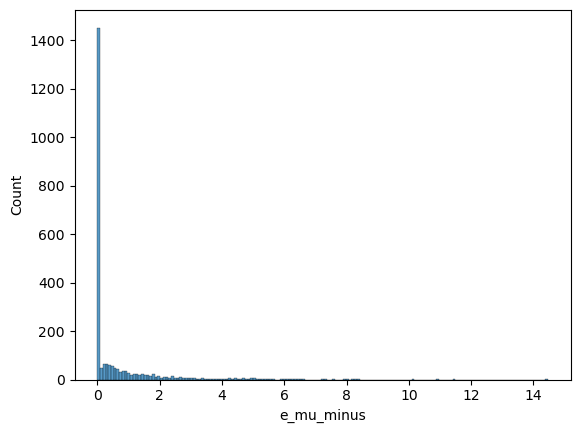

In [11]:
sns.histplot(observables, x='e_mu_minus')

- let us systematically calculate obvservables for all files

In [12]:

energies = [
    14.21, 17.90, 22.53, 28.37, 35.71, 44.964, 56.60, 71.26, 89.71, 
    112.94, 142.19, 179.00, 225.35, 283.70, 357.16, 449.64, 566.07, 712.64, 897.16,
    1129.46, 1421.90,
] 
#processes = ["CC_numu", "CC_nuebar", "NC_numu", "NC_nuebar","0.125GeV","0.5GeV","1GeV","3.16GeV","7.94GeV","15.84GeV","20GeV"]
processes = ["19.95GeV"]
# Loop through all energies
for process in processes: 
    for energy in energies:
        filename = f"output_events_{process}/events_{str(energy)}.csv.zip"
        
        # Check if the file exists
        if not os.path.isfile(filename):
            print(f"File not found: {filename}")
            continue

        print(process, energy)
        data = pd.read_csv(filename)
        
        # Check if DataFrame is empty
        if data.empty:
            print(f"Data is empty for {filename}")
            continue
        
        # Check if 'ievent' column exists
        if 'ievent' not in data.columns:
            print(f"Column 'ievent' not found in {filename}")
            continue
        
        # Check if the first row has a valid value
        if 0 not in data.index or np.isnan(data.loc[0, 'ievent']):
            print(f"Fixing DataFrame for {filename}")
            data = fix_dataframe(data)
        
        # Calculate observables and save
        observables = calculate_observables(data)
        csv_file = f"output_events_{process}/observables_{str(energy)}.csv.zip"
        observables.to_csv(csv_file, index=False, compression='zip')


File not found: output_events_19.95GeV/events_14.21.csv.zip
File not found: output_events_19.95GeV/events_17.9.csv.zip
File not found: output_events_19.95GeV/events_22.53.csv.zip
File not found: output_events_19.95GeV/events_28.37.csv.zip
File not found: output_events_19.95GeV/events_35.71.csv.zip
File not found: output_events_19.95GeV/events_44.964.csv.zip
File not found: output_events_19.95GeV/events_56.6.csv.zip
File not found: output_events_19.95GeV/events_71.26.csv.zip
File not found: output_events_19.95GeV/events_89.71.csv.zip
File not found: output_events_19.95GeV/events_112.94.csv.zip
File not found: output_events_19.95GeV/events_142.19.csv.zip
File not found: output_events_19.95GeV/events_179.0.csv.zip
File not found: output_events_19.95GeV/events_225.35.csv.zip
19.95GeV 283.7
Data is empty for output_events_19.95GeV/events_283.7.csv.zip
19.95GeV 357.16


/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  truth_energy, pid, px, py, pz, e  = row[2], row[3], row[4], row[5], row[6], row[7]
/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  parent_pid1 = row[8]


19.95GeV 449.64


/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  truth_energy, pid, px, py, pz, e  = row[2], row[3], row[4], row[5], row[6], row[7]
/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  parent_pid1 = row[8]


19.95GeV 566.07


...

/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  truth_energy, pid, px, py, pz, e  = row[2], row[3], row[4], row[5], row[6], row[7]
/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  parent_pid1 = row[8]


19.95GeV 1129.46


/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  truth_energy, pid, px, py, pz, e  = row[2], row[3], row[4], row[5], row[6], row[7]
/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  parent_pid1 = row[8]


19.95GeV 1421.9


/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  truth_energy, pid, px, py, pz, e  = row[2], row[3], row[4], row[5], row[6], row[7]
/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3120983717.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  parent_pid1 = row[8]


## Analysis

### Load all events 

Explanation for file format of MC_-14_3TeV_with_cut_with_final.txt: The first column in the file is energy in GeV. The second column is the flux of $\nu_{\mu}$ per year. The third column is the flux of $\bar\nu_{e}$ per year. The remaining columns are for cross sections of the different charged and neutral current processes for $\nu_{\mu}$ and $\bar\nu_{e}$ in units of $cm^{2}$. The cross sections have been obtained using pythia.SigmaGen() and compared with cross-section produced by GENIE. The last two columns correspond to cross section at $\lambda_{\mu\mu}$=1 for the two signals at mass 125MeV and 20 GeV. The cross section has been obtained using MADGRAPH. For the two signals, the flux of incoming neutrinos is considered to be that of $\nu_{\mu}$ as it is the source from which signals originate.

To get the event weight, we divide the number of interacting neutrinos per year by the number of monte carlo events generated to normalize it. 
\begin{equation}
N{\nu}_{\mu} =\frac{\sigma\times\rho\times l_{det}\times N_{inc}}{m_{p}} 
\end{equation}

Here, $\sigma\times10^{-36}$ is the cross section in $cm^{2}$, $\rho$ is the density of iron in $g/cm^{3}$, $l_{det}$ is the length of detector in centimeters, $N_{inc}$ is the number of incident neutrinos per year and $m_p$ is the mass of proton in gram. 

In [13]:
def load_everything(scaling_file='MC_-14_3TeV_with_cut_with_final.txt',big_det=False):
    
    #initialize numbers
    rho = 7.874            # density of iron in g/cm3
    mass = 1.67e-24        # mass of proton in g
    if big_det:l_det = 4042.54 
    else:l_det = 4.0425 
                         # length of detector for iron for 10 kg in cm
    mul = rho*l_det/mass   # area density, in 1/cm2 

    #initialize output 
    all_data = None
    
    #import data on fluxes and cross sections
    scaling_data = pd.read_csv(scaling_file, delim_whitespace=True) 
    scaling_data['energy'] = round(scaling_data['energy'],0)
    
    #loop over datasets 
    datasets = ['NC_nuebar', 'CC_nuebar', 'CC_numu', 'NC_numu',"0.125GeV","0.5GeV","1GeV","3.16GeV","7.94GeV","15.84GeV","19.95GeV"]
    
    for dataset in datasets:
        
        # get all files and loop over them
        dirname = 'output_events_' + dataset  
        directory = pathlib.Path(dirname)
        files = sorted(directory.rglob('observables_*.csv.zip'))
        
        #import data on generated event rates
        generated_data_name = dirname+"/generated_events.json"
        with open(generated_data_name, "r") as f: generated_data_raw = json.load(f)
        generated_data = {int(float(key)): value for key, value in generated_data_raw.items()}

        for file in files:
            #logging
            #print("load file: "+ str(file))
            
            # get beam energy
            energy = float(str(file).split('_')[-1].replace('.csv.zip', ''))
                
            # load data, get observables
            observables = pd.read_csv(str(file))
            observables['set'] = dataset
            print("load file: "+ str(file), len(observables))
            
            ### obtain number of events (allows for different nevents for different energies)
            nevent = generated_data[int(energy)]
            
            # calculate scaling factor            
            scaling_row = scaling_data[scaling_data['energy'] == round(energy,0)]
            
            cross_section = scaling_row[dataset].values[0]
            if dataset in ["0.125GeV","0.5GeV","1GeV","3.16GeV","7.94GeV","15.84GeV","19.95GeV"]:flux = scaling_row["numu"+"_flux"].values[0]
            else:flux = scaling_row[dataset[3:]+"_flux"].values[0]
            #flux = scaling_row[dataset[3:]+"_flux"].values[0]  
            weight = ((cross_section * flux * mul)/nevent)    
            observables['weight'] = weight
            
            # combine data
            if all_data is None: all_data = observables
            else:all_data = pd.concat([all_data, observables])
    
    return all_data.reset_index(drop=True)


In [14]:
data0 = load_everything(scaling_file='MC_-14_3TeV_with_cut_with_final_output_modified.txt',big_det=False)

/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/3942712217.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  scaling_data = pd.read_csv(scaling_file, delim_whitespace=True)


load file: output_events_NC_nuebar/observables_112.94.csv.zip 15598
load file: output_events_NC_nuebar/observables_1129.46.csv.zip 119176
load file: output_events_NC_nuebar/observables_14.21.csv.zip 1162
load file: output_events_NC_nuebar/observables_142.19.csv.zip 18674
load file: output_events_NC_nuebar/observables_1421.9.csv.zip 130966
load file: output_events_NC_nuebar/observables_17.9.csv.zip 1838
load file: output_events_NC_nuebar/observables_179.0.csv.zip 21699
load file: output_events_NC_nuebar/observables_22.53.csv.zip 2717
load file: output_events_NC_nuebar/observables_225.35.csv.zip 25585
load file: output_events_NC_nuebar/observables_28.37.csv.zip 3673
load file: output_events_NC_nuebar/observables_283.7.csv.zip 29544
load file: output_events_NC_nuebar/observables_35.71.csv.zip 4919
load file: output_events_NC_nuebar/observables_357.16.csv.zip 33655
load file: output_events_NC_nuebar/observables_44.964.csv.zip 6642
load file: output_events_NC_nuebar/observables_449.64.csv.z

### Get event rates and histograms after cuts

- function that prints  

In [15]:
         
def get_rates(data, header=None):
    # Print header if provided
    if header is not None: 
        print(header + ":")

    # Initialize counters for the combined total
    total_background_real = 0
    total_background_mc = 0
    # Store signal results
    signals = {}
    # Get event rates and MC statistics for all processes
    for dataset in ['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar', "0.125GeV", "0.5GeV", "1GeV", "3.16GeV", "7.94GeV", "15.84GeV", "19.95GeV"]:
        n_mc = len(data[data['set'] == dataset])
        n_real = sum(data[data['set'] == dataset]['weight'])        
        # Add to the combined background total
        if "CC" in dataset or "NC" in dataset:
            total_background_real += n_real
            total_background_mc += n_mc
        else:
            signals[dataset] = n_real

        # Print dataset-specific rates
        print(f"   {dataset}: {n_real} (N_MC = {n_mc})")    
    # Print combined background total
    print(f"\nTotal Background events: {total_background_real} (N_MC = {total_background_mc})")    
    
    # Calculate and print Signal/√Background for each signal dataset
    if total_background_real > 0:
        signal_threshold = 2 * (total_background_real**0.5)
        print(f"\nSignal required for S/√B > 2: {signal_threshold:.3f}")
        print("\nSignal/√Background for each signal dataset (with Signal > 3):")
        print("Coupling adjustments to meet S/√B > 2:")

        for signal, n_real in signals.items():
            if n_real > 3:
                # Signal-to-background ratio
                ratio = n_real / (total_background_real**0.5)
                if ratio > 2:
                    print(f"   {signal}: {ratio:.3f}")
                    
                    # Required coupling scaling factor
                    scaling_factor = (signal_threshold / n_real)**0.5
                    print(f"      Coupling scaling factor for {signal}: {scaling_factor:.3f}")
                else:
                    print(f"   {signal}: Signal/√Background = {ratio:.3f}, does not meet the threshold.")
            else:
                print(f"   {signal}: Signal = {n_real}, does not meet the minimum threshold of 3.")
    else:
        print("\nBackground events are zero; cannot compute Signal/√Background.")



    
def get_stacked_histogram(data, observable, bins, xlabel, xlog=False, coupling=1):
               
    # setup figure
    datasets = {'NC_numu':"red", 'NC_nuebar':"firebrick", 'CC_numu':"dodgerblue", 'CC_nuebar':"blue"}
    labels = {'CC_numu':r"CC $\nu_\mu$", 'CC_nuebar':r"CC $\nu_e$", 'NC_numu':r"NC $\nu_\mu$", 'NC_nuebar':r"NC $\nu_e$"}
    matplotlib.rcParams.update({'font.size': 14})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(12,4.5))
    
    #plot background 
    ax1 = plt.subplot(1,2,1)   
    ax2 = plt.subplot(1,2,2)   
    used_sets = []
    for idata, dataset in enumerate(datasets.keys()):
        
        #get stuff
        used_sets.append(dataset)
        subset = data[data['set'].isin(used_sets)]
        x, w = abs(subset[observable]), subset['weight']
        c, l = datasets[dataset], labels[dataset]
        
        # linear y-axis   
        ax1.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l,zorder=-idata)
        
        # log y axis
        ax2.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l,zorder=-idata)
    
    #plot signal 
    signals = {'0.125GeV':["$m_{\phi}$=125MeV","dashed"],'19.95GeV':[r"$m_{\phi}$=19.95GeV","dotted"]}
    for signal in signals.keys():
        
        #get stuff
        subset_bkg = data[data['set'].isin(datasets.keys())].copy()
        subset_sig = data[data['set']==signal].copy()
        subset_sig['weight'] =  subset_sig['weight'] * coupling**2 
        subset = pd.concat([subset_sig,subset_bkg])
        l,ls = signals[signal]
            
        #plot sig+bkg
        x, w = abs(subset[observable]), subset['weight']
        ax1.hist(x, weights=w, histtype='step', bins=bins, color='k', label = l, ls=ls)
        ax2.hist(x, weights=w, histtype='step', bins=bins, color='k', label = l, ls=ls)
        
        # plot sig
        x, w = abs(subset_sig[observable]), subset_sig['weight'] 
        ax1.hist(x, weights=w, histtype='step', bins=bins, color='gray',  ls=ls)
        ax2.hist(x, weights=w, histtype='step', bins=bins, color='gray',  ls=ls)
        
    
    # linear y-axis           
    if xlog: ax1.set_xscale("log")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(r"Interacting Neutrinos")
    ax1.legend(frameon=False, labelspacing=0, fontsize=12)
          
    # log y axis     
    if xlog: ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel(xlabel)
    ax2.set_ylim(ax2.get_ylim()[1]/1e3, ax2.get_ylim()[1])
    ax2.set_ylabel(r"Interacting Neutrinos")
    ax2.legend(frameon=False, labelspacing=0, fontsize=12)
         
    #finalize
    plt.tight_layout()
    plt.show()

<>:82: SyntaxWarning: invalid escape sequence '\p'
<>:82: SyntaxWarning: invalid escape sequence '\p'
/var/folders/rs/w38byv0x4wlcgrjkdwx6rm_c0000gp/T/ipykernel_25475/2402972761.py:82: SyntaxWarning: invalid escape sequence '\p'
  signals = {'0.125GeV':["$m_{\phi}$=125MeV","dashed"],'19.95GeV':[r"$m_{\phi}$=19.95GeV","dotted"]}


### 1.  select data with mu+ with E>100GeV

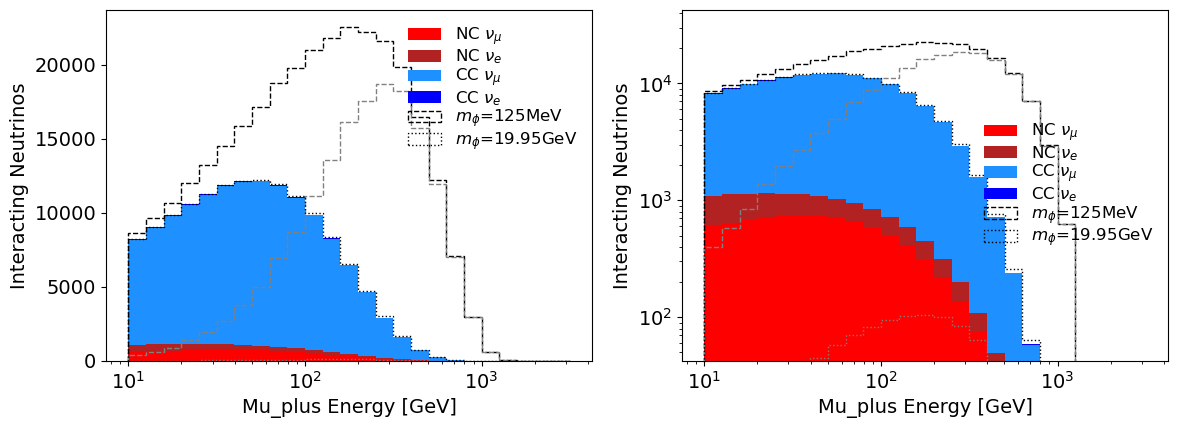

In [34]:
data = data0.copy()
get_stacked_histogram(
    data=data, 
    observable="e_mu_plus", 
    bins=np.logspace(1,3.5,25+1), 
    xlabel="Mu_plus Energy [GeV]", 
    xlog=True,
    coupling=1,
)

In [35]:
get_rates(data, header = None)

   CC_numu: 167727.8827782966 (N_MC = 2439503)
   CC_nuebar: 1399.8782487869212 (N_MC = 41533)
   NC_numu: 12820.568334550671 (N_MC = 410179)
   NC_nuebar: 9114.960216274152 (N_MC = 631249)
   0.125GeV: 166756.16868835568 (N_MC = 194725)
   0.5GeV: 106143.38346552607 (N_MC = 193104)
   1GeV: 77114.98313019447 (N_MC = 189821)
   3.16GeV: 32708.407245838043 (N_MC = 169330)
   7.94GeV: 8361.903037103955 (N_MC = 129350)
   15.84GeV: 992.9876214980754 (N_MC = 88023)
   19.95GeV: 992.8368026996819 (N_MC = 139080)

Total Background events: 191063.28957790838 (N_MC = 3522464)

Signal required for S/√B > 2: 874.216

Signal/√Background for each signal dataset (with Signal > 3):
Coupling adjustments to meet S/√B > 2:
   0.125GeV: 381.499
      Coupling scaling factor for 0.125GeV: 0.072
   0.5GeV: 242.831
      Coupling scaling factor for 0.5GeV: 0.091
   1GeV: 176.421
      Coupling scaling factor for 1GeV: 0.106
   3.16GeV: 74.829
      Coupling scaling factor for 3.16GeV: 0.163
   7.94GeV: 19.

In [36]:
data = data[data['e_mu_plus']>100]
get_rates(data, header = r"Events with $E_{\mu^+} >300$ GeV")

Events with $E_{\mu^+} >300$ GeV:
   CC_numu: 32294.044762558253 (N_MC = 262805)
   CC_nuebar: 44.26290638869251 (N_MC = 1163)
   NC_numu: 1714.1285374889321 (N_MC = 46658)
   NC_nuebar: 737.960191687693 (N_MC = 52451)
   0.125GeV: 133649.5700267159 (N_MC = 63669)
   0.5GeV: 84364.6864250731 (N_MC = 62204)
   1GeV: 60585.18865756567 (N_MC = 60474)
   3.16GeV: 25461.637785358336 (N_MC = 55780)
   7.94GeV: 6332.496466395244 (N_MC = 46280)
   15.84GeV: 693.4280701820533 (N_MC = 31653)
   19.95GeV: 614.0936160805331 (N_MC = 50724)

Total Background events: 34790.39639812357 (N_MC = 363077)

Signal required for S/√B > 2: 373.044

Signal/√Background for each signal dataset (with Signal > 3):
Coupling adjustments to meet S/√B > 2:
   0.125GeV: 716.536
      Coupling scaling factor for 0.125GeV: 0.053
   0.5GeV: 452.305
      Coupling scaling factor for 0.5GeV: 0.066
   1GeV: 324.816
      Coupling scaling factor for 1GeV: 0.078
   3.16GeV: 136.508
      Coupling scaling factor for 3.16GeV: 0.

### 2. Veto events with mu- with E<10 GeV

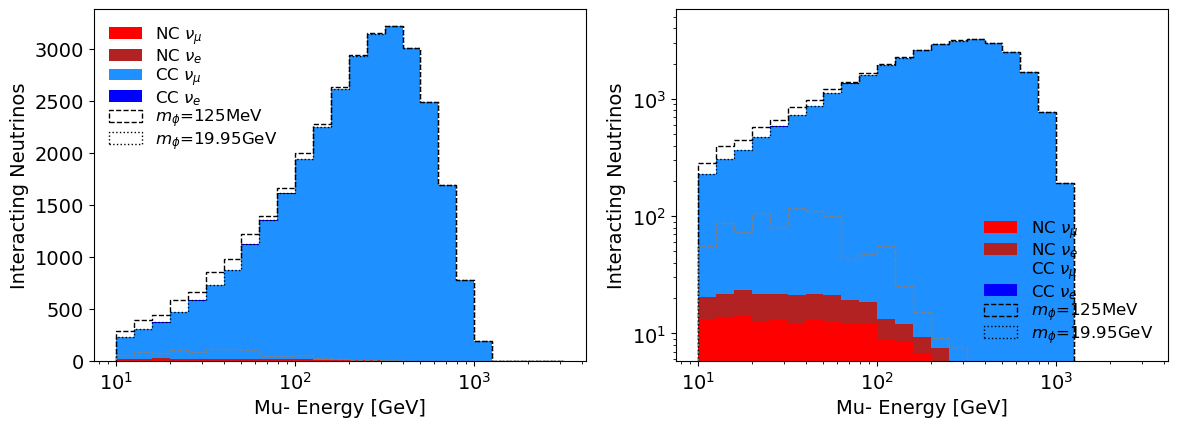

In [37]:
get_stacked_histogram(
    data=data, 
    observable="e_mu_minus", 
    bins=np.logspace(1,3.5,25+1), 
    xlabel="Mu- Energy [GeV]", 
    xlog=True,
)

In [38]:
data = data[data['e_mu_minus']<10]
get_rates(data, header = r"Events with $E_{\mu^-} <10$ GeV")

Events with $E_{\mu^-} <10$ GeV:
   CC_numu: 673.097688262817 (N_MC = 5150)
   CC_nuebar: 5.580370791454635 (N_MC = 153)
   NC_numu: 1547.0506885380432 (N_MC = 41919)
   NC_nuebar: 642.1509096291354 (N_MC = 45310)
   0.125GeV: 132703.71865296186 (N_MC = 63302)
   0.5GeV: 83901.57890991724 (N_MC = 61921)
   1GeV: 60272.2723223054 (N_MC = 60211)
   3.16GeV: 25384.06273755064 (N_MC = 55646)
   7.94GeV: 6323.881581010205 (N_MC = 46225)
   15.84GeV: 693.1410098093544 (N_MC = 31642)
   19.95GeV: 613.9674674299689 (N_MC = 50714)

Total Background events: 2867.8796572214505 (N_MC = 92532)

Signal required for S/√B > 2: 107.105

Signal/√Background for each signal dataset (with Signal > 3):
Coupling adjustments to meet S/√B > 2:
   0.125GeV: 2478.008
      Coupling scaling factor for 0.125GeV: 0.028
   0.5GeV: 1566.714
      Coupling scaling factor for 0.5GeV: 0.036
   1GeV: 1125.478
      Coupling scaling factor for 1GeV: 0.042
   3.16GeV: 474.003
      Coupling scaling factor for 3.16GeV: 0.06

### 3. EM energy

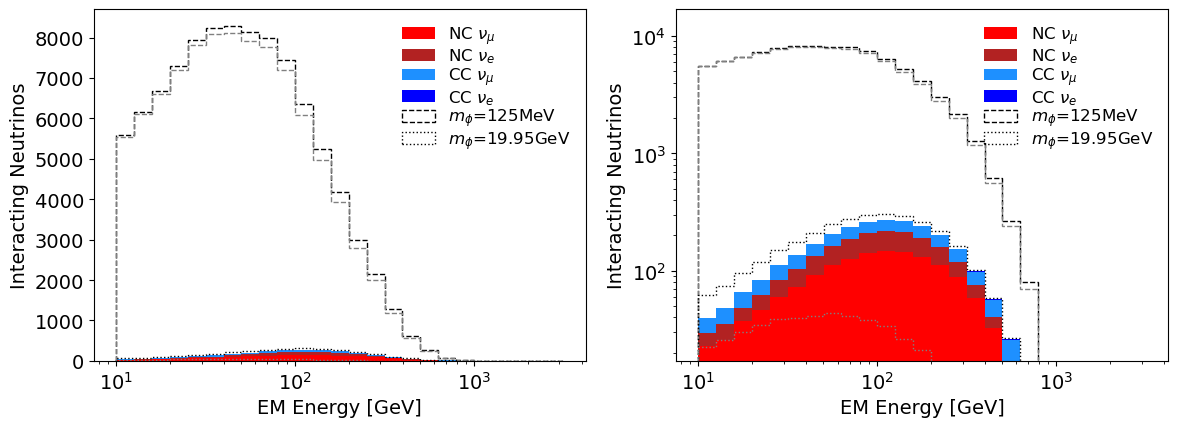

In [39]:
get_stacked_histogram(
    data=data, 
    observable="e_em", 
    bins=np.logspace(1,3.5,25+1), 
    xlabel="EM Energy [GeV]", 
    xlog=True,
)

In [40]:
data = data[data['e_em']<100]
get_rates(data, header = r"Events with $E_EM <100$ GeV")

Events with $E_EM <100$ GeV:
   CC_numu: 388.39070926766664 (N_MC = 3024)
   CC_nuebar: 0.15061517665476115 (N_MC = 4)
   NC_numu: 812.2826199384651 (N_MC = 19812)
   NC_nuebar: 339.57555185379636 (N_MC = 19509)
   0.125GeV: 110848.40995379056 (N_MC = 55146)
   0.5GeV: 69388.19421109094 (N_MC = 53492)
   1GeV: 49492.58808899895 (N_MC = 51653)
   3.16GeV: 20278.956799293854 (N_MC = 46668)
   7.94GeV: 4943.277025096604 (N_MC = 37955)
   15.84GeV: 549.8223884354986 (N_MC = 26198)
   19.95GeV: 506.3437108177686 (N_MC = 42696)

Total Background events: 1540.3994962365828 (N_MC = 42349)

Signal required for S/√B > 2: 78.496

Signal/√Background for each signal dataset (with Signal > 3):
Coupling adjustments to meet S/√B > 2:
   0.125GeV: 2824.313
      Coupling scaling factor for 0.125GeV: 0.027
   0.5GeV: 1767.946
      Coupling scaling factor for 0.5GeV: 0.034
   1GeV: 1261.024
      Coupling scaling factor for 1GeV: 0.040
   3.16GeV: 516.689
      Coupling scaling factor for 3.16GeV: 0.062

### 4. Charm Veto

### 4.1 Charm Veto 100%

In [41]:
# data = data[(data['has_charm']==0)]
# get_rates(data, header = r"Events without charm")

In [42]:
veto_prob = 0.8
data = data.copy()
data['ctag_prob'] = 1 - data['has_charm'] * veto_prob
data['weight'] = data['weight'] * data['ctag_prob']
get_rates(data, header = r"Events without charm")

Events without charm:
   CC_numu: 78.0861619437568 (N_MC = 3024)
   CC_nuebar: 0.07203070753907154 (N_MC = 4)
   NC_numu: 164.0289652033931 (N_MC = 19812)
   NC_nuebar: 68.59614543431927 (N_MC = 19509)
   0.125GeV: 104681.00552423255 (N_MC = 55146)
   0.5GeV: 65886.11079709233 (N_MC = 53492)
   1GeV: 47363.183814782824 (N_MC = 51653)
   3.16GeV: 19675.33218663743 (N_MC = 46668)
   7.94GeV: 4875.723369370477 (N_MC = 37955)
   15.84GeV: 547.7977827093515 (N_MC = 26198)
   19.95GeV: 505.20915817269145 (N_MC = 42696)

Total Background events: 310.78330328900824 (N_MC = 42349)

Signal required for S/√B > 2: 35.258

Signal/√Background for each signal dataset (with Signal > 3):
Coupling adjustments to meet S/√B > 2:
   0.125GeV: 5937.984
      Coupling scaling factor for 0.125GeV: 0.018
   0.5GeV: 3737.361
      Coupling scaling factor for 0.5GeV: 0.023
   1GeV: 2686.656
      Coupling scaling factor for 1GeV: 0.027
   3.16GeV: 1116.075
      Coupling scaling factor for 3.16GeV: 0.042
   7.94

In [43]:
data = data[data['e_visible']<500]
get_rates(data, header = r"Events with $E_visible <500$ GeV")

Events with $E_visible <500$ GeV:
   CC_numu: 27.354846794109456 (N_MC = 1466)
   CC_nuebar: 0.07203070753907154 (N_MC = 4)
   NC_numu: 71.43838893064186 (N_MC = 7536)
   NC_nuebar: 37.77580392956884 (N_MC = 8465)
   0.125GeV: 64864.36744715897 (N_MC = 40331)
   0.5GeV: 40669.73009189577 (N_MC = 39044)
   1GeV: 29184.867190720084 (N_MC = 37603)
   3.16GeV: 11990.498868542205 (N_MC = 33690)
   7.94GeV: 3012.2854286757783 (N_MC = 27465)
   15.84GeV: 371.16922722772233 (N_MC = 19845)
   19.95GeV: 385.6580462347815 (N_MC = 33912)

Total Background events: 136.64107036185922 (N_MC = 17471)

Signal required for S/√B > 2: 23.379

Signal/√Background for each signal dataset (with Signal > 3):
Coupling adjustments to meet S/√B > 2:
   0.125GeV: 5549.011
      Coupling scaling factor for 0.125GeV: 0.019
   0.5GeV: 3479.210
      Coupling scaling factor for 0.5GeV: 0.024
   1GeV: 2496.704
      Coupling scaling factor for 1GeV: 0.028
   3.16GeV: 1025.762
      Coupling scaling factor for 3.16GeV: 

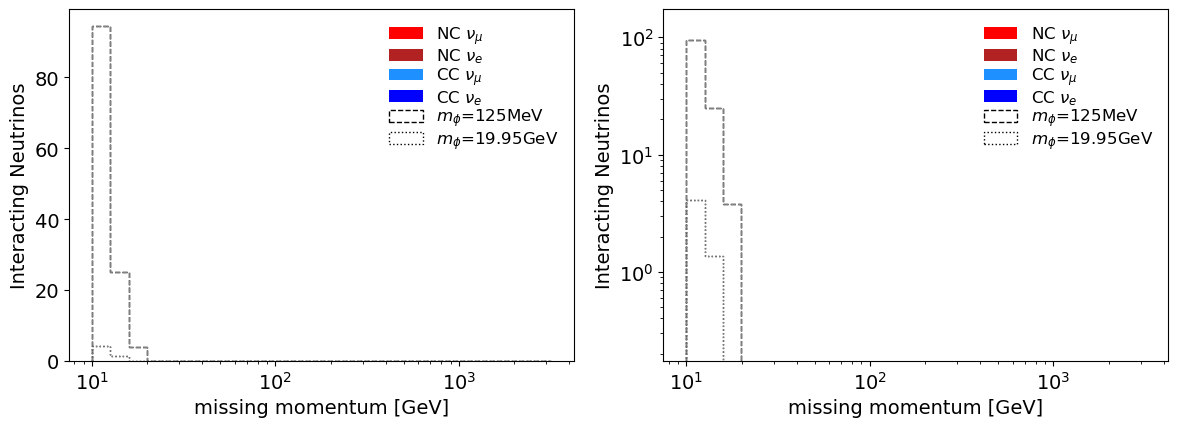

In [26]:
get_stacked_histogram(
    data=data, 
    observable="pt_mis", 
    bins=np.logspace(1,3.5,25+1), 
    xlabel="missing momentum [GeV]", 
    xlog=True,
)

In [32]:
data = data[abs(data['pt_mis']) >7]
get_rates(data, header = r"Events with $pt_missing >3$ GeV")

Events with $pt_missing >3$ GeV:
   CC_numu: 0 (N_MC = 0)
   CC_nuebar: 0 (N_MC = 0)
   NC_numu: 0.0344271035468364 (N_MC = 5)
   NC_nuebar: 0.027351281361372014 (N_MC = 8)
   0.125GeV: 502.66650987120045 (N_MC = 172)
   0.5GeV: 558.0141450778747 (N_MC = 291)
   1GeV: 491.1939522125873 (N_MC = 348)
   3.16GeV: 409.3306624993183 (N_MC = 676)
   7.94GeV: 175.3482303320062 (N_MC = 991)
   15.84GeV: 20.501061550818374 (N_MC = 727)
   19.95GeV: 16.27087772581396 (N_MC = 1126)

Total Background events: 0.06177838490820842 (N_MC = 13)

Signal required for S/√B > 2: 0.497

Signal/√Background for each signal dataset (with Signal > 3):
Coupling adjustments to meet S/√B > 2:
   0.125GeV: 2022.375
      Coupling scaling factor for 0.125GeV: 0.031
   0.5GeV: 2245.055
      Coupling scaling factor for 0.5GeV: 0.030
   1GeV: 1976.217
      Coupling scaling factor for 1GeV: 0.032
   3.16GeV: 1646.857
      Coupling scaling factor for 3.16GeV: 0.035
   7.94GeV: 705.477
      Coupling scaling factor for

In [ ]:
data = data[abs(data['ht']) >1]
get_rates(data, header = r"Events with $pt_missing >3$ GeV")